In [7]:
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import json
import os
from torch.utils.data import DataLoader
from datasets import load_dataset, load_from_disk

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms, models

# for file system
import os

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# for model evaluation
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sn
import numpy as np

# for randimization
import random
import json
# type
from typing import List , Dict , Tuple
import tqdm

import os
import gc
import random
import logging

import torch
import sacrebleu
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)
from peft import LoraConfig, TaskType, get_peft_model, PeftModel


device = torch.device("cuda")
x = torch.ones(1, device=device)

In [2]:
device

device(type='cuda')

In [3]:
urdu_eng= load_dataset("HaiderSultanArc/MT-Urdu-English")
print(urdu_eng.items())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/603 [00:00<?, ?B/s]

data/train-00000-of-00003-43802235375676(…):   0%|          | 0.00/233M [00:00<?, ?B/s]

data/train-00001-of-00003-4b574fda4b8ddf(…):   0%|          | 0.00/233M [00:00<?, ?B/s]

data/train-00002-of-00003-1413ab686eef16(…):   0%|          | 0.00/233M [00:00<?, ?B/s]

data/test-00000-of-00001-8d5468f2cad985f(…):   0%|          | 0.00/175M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5646138 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1411535 [00:00<?, ? examples/s]

dict_items([('train', Dataset({
    features: ['en', 'ur'],
    num_rows: 5646138
})), ('test', Dataset({
    features: ['en', 'ur'],
    num_rows: 1411535
}))])


In [8]:
MODEL_ID    = "facebook/nllb-200-distilled-600M"
SRC_LANG    = "eng_Latn"
TGT_LANG    = "urd_Arab"
MAX_LEN     = 128
SEED        = 42
OUTPUT_DIR  = "nllb_lora_mt"
N_SAMPLES   = 5

In [9]:

LORA_CFG = dict(
    r              = 16,
    lora_alpha     = 32,
    lora_dropout   = 0.1,
    target_modules = ["q_proj", "v_proj"],
    bias           = "none",
    task_type      = TaskType.SEQ_2_SEQ_LM,
)


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.src_lang = SRC_LANG

def tokenize(batch):
    model_inputs = tokenizer(
        batch["en"],
        max_length  = MAX_LEN,
        truncation  = True,
        padding     = False,
    )
    labels = tokenizer(
        text_target = batch["ur"],
        max_length  = MAX_LEN,
        truncation  = True,
        padding     = False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

def tokenize_splits(train, test) -> dict:
    tok = {}
    for name, ds in [("train", train), ("test", test)]:
        tok[name] = ds.map(
            tokenize,
            batched        = True,
            remove_columns = ["en", "ur"],
            desc           = f"Tokenising {name}",
        )
    return tok




In [ ]:

train_data = urdu_eng["train"].shuffle(seed=SEED).select(range(100_000))
test_data  = urdu_eng["test"].shuffle(seed=SEED).select(range(10_000))

gc.collect()

print(f"✅ Train : {len(train_data):,} records")
print(f"✅ Test  : {len(test_data):,} records")
print(f"   Sample: {train_data[0]}")

In [ ]:
urdu_eng['train'][9]

{'en': 'Which is what happened in 2008.', 'ur': 'سال 2008 میں کیا ہوا'}

In [32]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

In [4]:
torch.cuda.empty_cache()

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.src_lang = SRC_LANG

def tokenize(batch):
    model_inputs = tokenizer(
        batch["en"],
        max_length  = MAX_LEN,
        truncation  = True,
        padding     = False,
    )
    labels = tokenizer(
        text_target = batch["ur"],
        max_length  = MAX_LEN,
        truncation  = True,
        padding     = False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

def tokenize_splits(train, test) -> dict:
    tok = {}
    for name, ds in [("train", train), ("test", test)]:
        tok[name] = ds.map(
            tokenize,
            batched        = True,
            remove_columns = ["en", "ur"],
            desc           = f"Tokenising {name}",
        )
    return tok





In [ ]:
tokenized = tokenize_splits(train_data, test_data)
print("✅ Tokenisation done")
print(f"   Train : {len(tokenized['train']):,}")
print(f"   Test  : {len(tokenized['test']):,}")




In [ ]:
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    labels = [
        [(t if t != -100 else tokenizer.pad_token_id) for t in label]
        for label in labels
    ]
    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    result = sacrebleu.corpus_bleu(decoded_preds, [[r] for r in decoded_labels])
    return {"bleu": round(result.score, 4)}

print("✅ Metric ready")




In [36]:
base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, device_map="auto")
model      = get_peft_model(base_model, LoraConfig(**LORA_CFG))
model.print_trainable_parameters()




Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 2,359,296 || all params: 1,404,497,920 || trainable%: 0.1680


In [44]:
TRAIN_ARGS = dict(
    num_train_epochs            = 1,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 4,
    gradient_accumulation_steps = 4,     # effective batch = 16
    warmup_steps                = 50,
    learning_rate               = 3e-4,
    fp16                        = True,
    optim                       = "adafactor",
    predict_with_generate       = True,
    generation_max_length       = MAX_LEN,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "bleu",
    greater_is_better           = True,
    logging_steps               = 100,
    report_to                   = "none",
)

In [45]:
train_data = urdu_eng["train"].shuffle(seed=SEED).select(range(20_000))
test_data  = urdu_eng["test"].shuffle(seed=SEED).select(range(2_000))

In [ ]:
tokenized = tokenize_splits(train_data, test_data)
print(" Tokenisation done")
print(f"   Train : {len(tokenized['train']):,}")
print(f"   Test  : {len(tokenized['test']):,}")




Tokenising train:   0%|          | 0/20000 [00:00<?, ? examples/s]

Tokenising test:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Tokenisation done
   Train : 20,000
   Test  : 2,000


In [47]:
collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)
args     = Seq2SeqTrainingArguments(output_dir=OUTPUT_DIR, **TRAIN_ARGS)

trainer = Seq2SeqTrainer(
    model           = model,
    args            = args,
    train_dataset   = tokenized["train"],
    eval_dataset    = tokenized["test"],
    processing_class = tokenizer,        # ← replaces tokenizer=
    data_collator   = collator,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()
trainer.save_model(OUTPUT_DIR)
print(f"✅ Model saved → {OUTPUT_DIR}")



Epoch,Training Loss,Validation Loss,Bleu
1,10.552296,2.513487,20.448000


✅ Model saved → nllb_lora_idioms


In [ ]:
metrics = trainer.evaluate(tokenized["test"])
bleu    = metrics.get("eval_bleu", 0.0)
print(f"\n Test BLEU : {bleu:.2f}")





✅ Test BLEU : 20.45


In [49]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()

base       = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, device_map="auto")
best_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
best_model = best_model.merge_and_unload()
best_model.eval()
print("✅ Best model loaded for inference")



Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Best model loaded for inference


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:683: UserWarning: Input and output embeddings are no longer tied after merging. Setting `tie_word_embeddings=False` in the model config.
  warnings.warn(


In [52]:
#══════════════════════════════════════════════════════════════════════════════
# CELL 12 — Sample outputs
# ══════════════════════════════════════════════════════════════════════════════
device  = next(best_model.parameters()).device
samples = random.sample(list(test_data), N_SAMPLES)

print(f"\n{'━'*60}")
print(f"  SAMPLE TRANSLATIONS")
print(f"{'━'*60}")

for i, row in enumerate(samples, 1):
    inputs = tokenizer(
        row["en"],
        return_tensors = "pt",
        max_length     = MAX_LEN,
        truncation     = True,
    ).to(device)

    forced_bos = tokenizer.convert_tokens_to_ids(TGT_LANG)
    with torch.no_grad():
        out = best_model.generate(
            **inputs,
            forced_bos_token_id = forced_bos,
            max_new_tokens      = MAX_LEN,
            num_beams           = 4,
        )

    pred      = tokenizer.decode(out[0], skip_special_tokens=True)
    sent_bleu = sacrebleu.sentence_bleu(pred, [row["ur"]]).score

    print(f"\n[{i}] EN        : {row['en']}")
    print(f"    Reference : {row['ur']}")
    print(f"    Predicted : {pred}")
    print(f"    BLEU      : {sent_bleu:.2f}")

print(f"\n{'━'*60}")


#


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SAMPLE TRANSLATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[1] EN        : Lord, save me and my family from their deeds."
    Reference : اے میرے پروردگار! مجھے اور میرے گھر والوں کو اس عمل (کے وبال) سے جو یہ کرتے ہیں نجات عطا فرما۔
    Predicted : اے میرے رب مجھے اور میرے گھر والوں کو ان کے اعمال سے بچا لے۔
    BLEU      : 21.13

[2] EN        : How about the Midwest?
    Reference : مشرق وسطی کیا ہے؟
    Predicted : مشرق وسطی کے بارے میں کیا خیال ہے؟
    BLEU      : 13.13

[3] EN        : He invokes one whose harm is closer than his benefit - how wretched the protector and how wretched the associate.
    Reference : ایسے کو پکارتا ہے جس کا ضرر اس کے نفع سے نزدیک تر ہے ایسا کارساز بھی برا اور ایسا رفیق بھی برا ہے
    Predicted : وہ اس شخص کو پکارتا ہے جس کا نقصان اس کے فائدے سے زیادہ قریب ہے اور اس کا مددگار کتنا برا ہے اور اس کا شریک کتنا برا ہے
    BLEU      : 16.33

[4] EN        : As they did, t

In [54]:

buckets = {"short (1-5)": [], "medium (6-20)": [], "long (21+)": []}

sample_for_analysis = random.sample(list(test_data), 300)

for row in sample_for_analysis:
    n = len(row["en"].split())
    if n <= 5:
        buckets["short (1-5)"].append(row)
    elif n <= 20:
        buckets["medium (6-20)"].append(row)
    else:
        buckets["long (21+)"].append(row)

print(f"\n{'━'*60}")
print(f"  ERROR ANALYSIS — by sentence length")
print(f"{'━'*60}")

bucket_bleus = {}
for bucket_name, rows in buckets.items():
    if not rows:
        continue
    preds, refs = [], []
    for row in rows:
        inputs = tokenizer(
            row["en"],
            return_tensors = "pt",
            max_length     = MAX_LEN,
            truncation     = True,
        ).to(device)
        forced_bos =tokenizer.convert_tokens_to_ids(TGT_LANG)

        with torch.no_grad():
            out = best_model.generate(
                **inputs,
                forced_bos_token_id = forced_bos,
                max_new_tokens      = MAX_LEN,
                num_beams           = 4,
            )
        preds.append(tokenizer.decode(out[0], skip_special_tokens=True))
        refs.append(row["ur"])

    bleu = sacrebleu.corpus_bleu(preds, [[r] for r in refs]).score
    bucket_bleus[bucket_name] = round(bleu, 2)
    print(f"\n  [{bucket_name}]  BLEU = {bleu:.2f}  (n={len(rows)})")

    # Worst example
    worst_score, worst_en, worst_ref, worst_pred = float("inf"), "", "", ""
    for row, pred in zip(rows, preds):
        s = sacrebleu.sentence_bleu(pred, [row["ur"]]).score
        if s < worst_score:
            worst_score, worst_en, worst_ref, worst_pred = s, row["en"], row["ur"], pred

    print(f"  Worst (BLEU={worst_score:.2f}):")
    print(f"    EN  : {worst_en}")
    print(f"    REF : {worst_ref}")
    print(f"    PRED: {worst_pred}")

print(f"\n{'━'*60}")





━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ERROR ANALYSIS — by sentence length
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [short (1-5)]  BLEU = 0.00  (n=56)
  Worst (BLEU=0.00):
    EN  : 6.2 Resistance to change
    REF : 4.12 راستہ بدلنے تک
    PRED: 6.2 تبدیلی کے لئے مزاحمت

  [medium (6-20)]  BLEU = 12.33  (n=209)
  Worst (BLEU=0.00):
    EN  : See them at . . .
    REF : زرا کرکے دیکھیں ۔۔۔
    PRED: ان کو دیکھ کر . . .

  [long (21+)]  BLEU = 15.88  (n=35)
  Worst (BLEU=0.00):
    EN  : They said, ‘Reuben, we had rather bury you than to have you become unchaste.’ and that is the law of this Church.”
    REF : قالوا يا ويلنا إنا كنا ظالمينقَالُواْ يَا وَيْلَنَا إِنَّا كُنَّا ظَالِمِينَTahir ul Qadri وہ کہنے لگے: ہائے شومئ قسمت!
    PRED: انہوں نے کہا کہ اے رُوبین ہم تجھے دفن کرنا چاہتے ہیں کہ تو ناپاک ہو جائے اور یہ ہی اس کلیسیا کی شریعت ہے۔

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


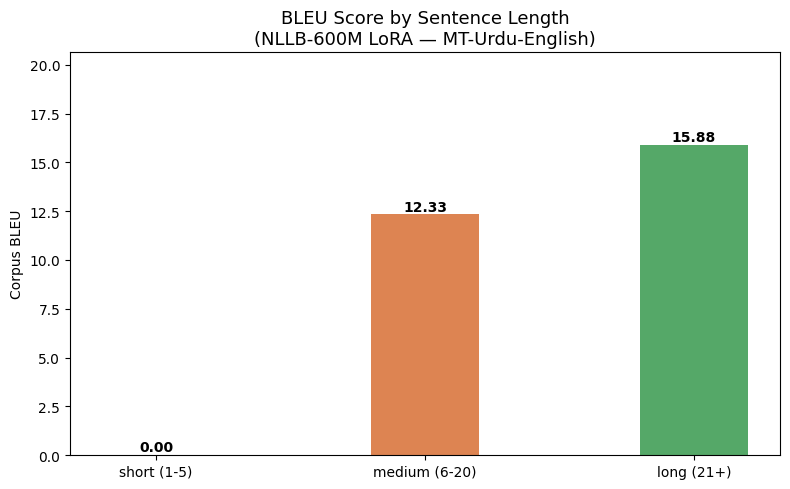

✅ Saved → bleu_by_length.png


In [55]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    bucket_bleus.keys(),
    bucket_bleus.values(),
    color=["#4C72B0", "#DD8452", "#55A868"],
    width=0.4,
)
for bar, val in zip(bars, bucket_bleus.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f"{val:.2f}", ha="center", fontweight="bold")

plt.title("BLEU Score by Sentence Length\n(NLLB-600M LoRA — MT-Urdu-English)", fontsize=13)
plt.ylabel("Corpus BLEU")
plt.ylim(0, max(bucket_bleus.values()) * 1.3)
plt.tight_layout()
plt.savefig("bleu_by_length.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → bleu_by_length.png")



In [56]:
from datasets import load_dataset
import re

sample  = urdu_eng["train"].shuffle(seed=42).select(range(5000))

# Count problematic pairs
starts_with_number = 0
length_mismatch    = 0
both_issues        = 0

for row in sample:
    en, ur = row["en"].strip(), row["ur"].strip()

    is_numbered  = bool(re.match(r"^\d+[\.\d]*\s", en) or re.match(r"^\d+[\.\d]*\s", ur))
    en_len, ur_len = len(en.split()), len(ur.split())
    is_mismatched = ur_len == 0 or not (0.3 <= en_len / ur_len <= 3.0)

    if is_numbered:   starts_with_number += 1
    if is_mismatched: length_mismatch    += 1
    if is_numbered and is_mismatched: both_issues += 1

print(f"Total sampled         : 5,000")
print(f"Starts with number    : {starts_with_number} ({starts_with_number/50:.1f}%)")
print(f"Length mismatch       : {length_mismatch} ({length_mismatch/50:.1f}%)")
print(f"Both issues           : {both_issues} ({both_issues/50:.1f}%)")

Total sampled         : 5,000
Starts with number    : 195 (3.9%)
Length mismatch       : 5 (0.1%)
Both issues           : 0 (0.0%)


In [57]:
import re

def clean_dataset(dataset):
    def is_valid(row):
        en = row["en"].strip()
        ur = row["ur"].strip()

        # Remove pairs starting with numbers (section headers like "6.2 Resistance...")
        if re.match(r"^\d+[\.\d]*\s", en) or re.match(r"^\d+[\.\d]*\s", ur):
            return False

        # Remove length mismatched pairs
        en_len, ur_len = len(en.split()), len(ur.split())
        if ur_len == 0 or not (0.3 <= en_len / ur_len <= 3.0):
            return False

        return True

    cleaned = dataset.filter(is_valid, desc="Cleaning dataset")
    print(f"Before : {len(dataset):,}")
    print(f"After  : {len(cleaned):,}")
    print(f"Removed: {len(dataset) - len(cleaned):,} ({(len(dataset) - len(cleaned)) / len(dataset) * 100:.1f}%)")
    return cleaned

train_data = clean_dataset(urdu_eng['train'])
test_data  = clean_dataset(urdu_eng['test'])

Cleaning dataset:   0%|          | 0/5646138 [00:00<?, ? examples/s]

Cleaning dataset:   0%|          | 0/1411535 [00:00<?, ? examples/s]

Before : 2
After  : 2
Removed: 0 (0.0%)
Before : 2
After  : 2
Removed: 0 (0.0%)


In [78]:
import re

def clean_dataset(dataset):
    def is_valid(row):
        en = row["en"].strip()
        ur = row["ur"].strip()

        # Remove pairs starting with numbers (section headers like "6.2 Resistance...")
        if re.match(r"^\d+[\.\d]*\s", en) or re.match(r"^\d+[\.\d]*\s", ur):
            return False

        # Remove length mismatched pairs
        en_len, ur_len = len(en.split()), len(ur.split())
        if ur_len == 0 or not (0.3 <= en_len / ur_len <= 3.0):
            return False

        return True

    cleaned = dataset.filter(is_valid, desc="Cleaning dataset")
    print(f"Before : {len(dataset):,}")
    print(f"After  : {len(cleaned):,}")
    print(f"Removed: {len(dataset) - len(cleaned):,} ({(len(dataset) - len(cleaned)) / len(dataset) * 100:.1f}%)")
    return cleaned

train_data3 = clean_dataset(urdu_eng['train'])
test_data3  = clean_dataset(urdu_eng['test'])

Before : 5,646,138
After  : 5,431,977
Removed: 214,161 (3.8%)
Before : 1,411,535
After  : 1,358,430
Removed: 53,105 (3.8%)


In [80]:
train_data3 = train_data3.shuffle(seed=SEED).select(range(10_000))
test_data3  = test_data3.shuffle(seed=SEED).select(range(2_000))

In [59]:
len(train_data2)

20000

In [61]:
train_data

DatasetDict({
    train: Dataset({
        features: ['en', 'ur'],
        num_rows: 5431977
    })
    test: Dataset({
        features: ['en', 'ur'],
        num_rows: 1358430
    })
})

In [81]:
tokenized3 = tokenize_splits(train_data3, test_data3)
print("✅ Tokenisation done")
print(f"   Train : {len(tokenized2['train']):,}")
print(f"   Test  : {len(tokenized2['test']):,}")




✅ Tokenisation done
   Train : 10,000
   Test  : 2,000


In [86]:
gc.collect()
torch.cuda.empty_cache()

base_model2 = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID, device_map="auto")
model       = get_peft_model(base_model2, LoraConfig(**LORA_CFG))
model.print_trainable_parameters()

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 2,359,296 || all params: 1,404,497,920 || trainable%: 0.1680


In [69]:
collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)
args     = Seq2SeqTrainingArguments(output_dir=OUTPUT_DIR, **TRAIN_ARGS)

trainer = Seq2SeqTrainer(
    model           = model,
    args            = args,
    train_dataset   = tokenized3["train"],
    eval_dataset    = tokenized3["test"],
    processing_class = tokenizer,        # ← replaces tokenizer=
    data_collator   = collator,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()
trainer.save_model(OUTPUT_DIR)
print(f"✅ Model saved → {OUTPUT_DIR}")



Epoch,Training Loss,Validation Loss,Bleu
1,10.918556,2.577311,56.234100


✅ Model saved → nllb_lora_idioms


In [70]:

device  = next(best_model.parameters()).device
samples = random.sample(list(test_data3), N_SAMPLES)

print(f"\n{'━'*60}")
print(f"  SAMPLE TRANSLATIONS")
print(f"{'━'*60}")

for i, row in enumerate(samples, 1):
    inputs = tokenizer(
        row["en"],
        return_tensors = "pt",
        max_length     = MAX_LEN,
        truncation     = True,
    ).to(device)

    forced_bos = tokenizer.convert_tokens_to_ids(TGT_LANG)
    with torch.no_grad():
        out = best_model.generate(
            **inputs,
            forced_bos_token_id = forced_bos,
            max_new_tokens      = MAX_LEN,
            num_beams           = 4,
        )

    pred      = tokenizer.decode(out[0], skip_special_tokens=True)
    sent_bleu = sacrebleu.sentence_bleu(pred, [row["ur"]]).score

    print(f"\n[{i}] EN        : {row['en']}")
    print(f"    Reference : {row['ur']}")
    print(f"    Predicted : {pred}")
    print(f"    BLEU      : {sent_bleu:.2f}")

print(f"\n{'━'*60}")


#


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SAMPLE TRANSLATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[1] EN        : And he is still their captive!"
    Reference : وہ اب بھی اس کے زیراثر ہیں۔‘‘
    Predicted : اور وہ اب بھی ان کا قیدی ہے!
    BLEU      : 17.75

[2] EN        : time of day clock synchronization
    Reference : Chronos جوہری گھڑی Synchronizer
    Predicted : دن کی گھڑی کے وقت کی ہم آہنگی
    BLEU      : 5.52

[3] EN        : “Shut the door.”.
    Reference : ’’ دروازہ بند کر لو … ‘‘
    Predicted : دروازہ بند کرو
    BLEU      : 14.51

[4] EN        : “Nothing could give me greater pleasure.
    Reference : "میں زیادہ حوصلہ افزائی نہیں کرسکتا.
    Predicted : کچھ بھی مجھے اس سے زیادہ خوشی نہیں دے سکتا.
    BLEU      : 4.93

[5] EN        : In order to hand that off to them, it required a huge amount of technical untangling.
    Reference : اس کی حمایت کرنے کے لئے مشکل ہے، تکنیکی اہلکاروں کی ایک بڑی تعداد کو چھوڑنے کے لئے کہا.

In [76]:

buckets = {"short (1-5)": [], "medium (6-20)": [], "long (21+)": []}

sample_for_analysis = random.sample(list(test_data2), min(300, len(test_data)))

for row in sample_for_analysis:
    n = len(row["en"].split())
    if n <= 5:
        buckets["short (1-5)"].append(row)
    elif n <= 20:
        buckets["medium (6-20)"].append(row)
    else:
        buckets["long (21+)"].append(row)

print(f"\n{'━'*60}")
print(f"  ERROR ANALYSIS — by sentence length")
print(f"{'━'*60}")

bucket_bleus = {}
for bucket_name, rows in buckets.items():
    if not rows:
        continue
    preds, refs = [], []
    for row in rows:
        inputs = tokenizer(
            row["en"],
            return_tensors = "pt",
            max_length     = MAX_LEN,
            truncation     = True,
        ).to(device)
        forced_bos =tokenizer.convert_tokens_to_ids(TGT_LANG)

        with torch.no_grad():
            out = best_model.generate(
                **inputs,
                forced_bos_token_id = forced_bos,
                max_new_tokens      = MAX_LEN,
                num_beams           = 4,
            )
        preds.append(tokenizer.decode(out[0], skip_special_tokens=True))
        refs.append(row["ur"])

    bleu = sacrebleu.corpus_bleu(preds, [[r] for r in refs]).score
    bucket_bleus[bucket_name] = round(bleu, 2)
    print(f"\n  [{bucket_name}]  BLEU = {bleu:.2f}  (n={len(rows)})")

    # Worst example
    worst_score, worst_en, worst_ref, worst_pred = float("inf"), "", "", ""
    for row, pred in zip(rows, preds):
        s = sacrebleu.sentence_bleu(pred, [row["ur"]]).score
        if s < worst_score:
            worst_score, worst_en, worst_ref, worst_pred = s, row["en"], row["ur"], pred

    print(f"  Worst (BLEU={worst_score:.2f}):")
    print(f"    EN  : {worst_en}")
    print(f"    REF : {worst_ref}")
    print(f"    PRED: {worst_pred}")

print(f"\n{'━'*60}")





━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ERROR ANALYSIS — by sentence length
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [medium (6-20)]  BLEU = 43.43  (n=2)
  Worst (BLEU=5.37):
    EN  : Worship the God of truth and be truth tellers.
    REF : اور اللہ تعالیٰ سے سچا۔اور۔حقیقی تعلق پیدا کرنے کی کوشش کرو
    PRED: اللہ کی عبادت کرو اور سچے ہو جاؤ۔

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
